<img src="https://logos-marques.com/wp-content/uploads/2023/01/Walmart-Logo-500x281.png" alt="WALMART LOGO" />

# Walmart : predire les ventes hebdomadaires

## Description de l'entreprise 

Walmart Inc. est une multinationale americaine de la grande distribution qui exploite une chaine d'hypermarches, de grands magasins a prix reduits et de supermarches aux Etats-Unis. Son siege social se trouve a Bentonville, dans l'Arkansas. L'entreprise a ete fondee par Sam Walton en 1962.

## Projet 

Le service marketing de Walmart vous a demande de concevoir un modele d'apprentissage automatique capable d'estimer les ventes hebdomadaires de leurs magasins avec la meilleure precision possible. Ce modele leur permettrait de mieux comprendre l'influence des indicateurs economiques sur les ventes et pourrait servir a la planification de futures campagnes marketing.

## Objectifs 

Le projet peut etre divise en trois etapes :

- Partie 1 : effectuer une analyse exploratoire des donnees (EDA) et tous les pretraitements necessaires pour preparer les donnees a l'apprentissage automatique.
- Partie 2 : entrainer un modele de regression lineaire (ligne de base)
- Partie 3 : eviter le surapprentissage en entrainant un modele de regression regularise

## Portee de ce projet 

Pour ce projet, vous travaillerez avec un jeu de donnees contenant des informations sur les ventes hebdomadaires realisees par differents magasins Walmart, ainsi que d'autres variables telles que le taux de chomage ou le prix du carburant, qui pourraient s'averer utiles pour predire le volume des ventes. Ce jeu de donnees provient d'une competition Kaggle, mais nous y avons apporte quelques modifications.

## Livrable 

Pour mener a bien ce projet, votre equipe doit :

- Creer des visualisations
- Entrainer au moins un modele de regression lineaire sur l'ensemble de donnees, qui predit le montant des ventes hebdomadaires en fonction des autres variables
- Evaluer les performances du modele en utilisant une metrique pertinente pour les problemes de regression
- Interpreter les coefficients du modele pour identifier les caracteristiques importantes pour la prediction
- Entrainer au moins un modele avec regularisation (Lasso ou Ridge) pour reduire le surapprentissage

## Aides 

Pour vous aider a mener a bien ce projet, voici quelques conseils qui devraient vous etre utiles :

### Partie 1 : EDA et pretraitement des donnees

Commencez votre projet en explorant votre ensemble de donnees : creez des figures, calculez des statistiques, etc.

Ensuite, vous devrez effectuer un pretraitement des donnees. Des transformations specifiques devront egalement etre planifiees, par exemple sur la colonne Date qui ne peut pas etre incluse telle quelle dans le modele.

**Pretraitement a planifier avec pandas**

*Supprimez les lignes ou les valeurs cibles sont manquantes* : la variable cible (Y) correspond a la colonne Weekly_Sales. On ne fait jamais d'imputation sur la cible, car cela creerait un biais dans les predictions.

*Creation de caracteristiques exploitables a partir de la colonne Date* : soit la supprimer, soit creer de nouvelles colonnes numeriques (annee, mois, jour, jour de la semaine).

*Supprimer les lignes contenant des valeurs invalides ou aberrantes* : seront considerees comme aberrantes toutes les valeurs numeriques qui ne se situent pas dans la plage [X̄ − 3σ, X̄ + 3σ]. Cela concerne les colonnes : Temperature, Prix du carburant, IPC et Chomage.

**Pretraitements a planifier avec scikit-learn**

- Variables categorielles : Magasin, Indicateur_Vacances
- Variables numeriques : Temperature, Prix du carburant, IPC, Chomage, Annee, Mois, Jour, Jour de la semaine

### Partie 2 : Modele de base (regression lineaire)

Une fois le premier modele entraine, evaluer ses performances sur les ensembles d'entrainement et de test, puis analyser les valeurs des coefficients afin d'identifier les caracteristiques importantes pour la prediction (attribut `.coef_` de la classe `LinearRegression` de scikit-learn).

### Partie 3 : Lutter contre le surapprentissage

Entrainer un modele de regression lineaire regularise (`Ridge` ou `Lasso` de scikit-learn).

**Question bonus** : l'hyperparametre de force de regularisation peut etre ajuste finement grace a la classe `GridSearchCV` de scikit-learn, afin d'obtenir les meilleures predictions generalisees.

# PARTIE 1 : EDA et Preprocessing

## Etape 1 : Imports et chargement des donnees

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Charger le dataset
df = pd.read_csv('Walmart_Store_sales.csv')

print(f"Dataset : {df.shape[0]} lignes, {df.shape[1]} colonnes")
df.head()

Dataset : 150 lignes, 8 colonnes


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,6.0,18-02-2011,1572117.54,NaN,59.61,3.045,214.777523,6.858
1,13.0,25-03-2011,1807545.43,0.0,42.38,3.435,128.616064,7.470
2,17.0,27-07-2012,NaN,0.0,NaN,NaN,130.719581,5.936
3,11.0,NaN,1244390.03,0.0,84.57,NaN,214.556497,7.346
4,6.0,28-05-2010,1644470.66,0.0,78.89,2.759,212.412888,7.092


In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         150 non-null    float64
 1   Date          132 non-null    str    
 2   Weekly_Sales  136 non-null    float64
 3   Holiday_Flag  138 non-null    float64
 4   Temperature   132 non-null    float64
 5   Fuel_Price    136 non-null    float64
 6   CPI           138 non-null    float64
 7   Unemployment  135 non-null    float64
dtypes: float64(7), str(1)
memory usage: 10.8 KB


In [32]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,150.000000,1.360000e+02,138.000000,132.000000,136.000000,138.000000,135.000000
mean,9.866667,1.249536e+06,0.079710,61.398106,3.320853,179.898509,7.598430
std,6.231191,6.474630e+05,0.271831,18.378901,0.478149,40.274956,1.577173
min,1.000000,2.689290e+05,0.000000,18.790000,2.514000,126.111903,5.143000
25%,4.000000,6.050757e+05,0.000000,45.587500,2.852250,131.970831,6.597500
50%,9.000000,1.261424e+06,0.000000,62.985000,3.451000,197.908893,7.470000
75%,15.750000,1.806386e+06,0.000000,76.345000,3.706250,214.934616,8.150000
max,20.000000,2.771397e+06,1.000000,91.650000,4.193000,226.968844,14.313000


In [33]:
# Valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())
print(f"\nPourcentage de valeurs manquantes :")
print((df.isnull().sum() / len(df) * 100).round(1))

Valeurs manquantes par colonne :
Store            0
Date            18
Weekly_Sales    14
Holiday_Flag    12
Temperature     18
Fuel_Price      14
CPI             12
Unemployment    15
dtype: int64

Pourcentage de valeurs manquantes :
Store            0.0
Date            12.0
Weekly_Sales     9.3
Holiday_Flag     8.0
Temperature     12.0
Fuel_Price       9.3
CPI              8.0
Unemployment    10.0
dtype: float64


**Constat :** entre 8% et 12% de valeurs manquantes selon les colonnes, réparties sur toutes les variables (y compris la cible `Weekly_Sales`). Ce taux justifie un nettoyage attentif plutôt qu'une imputation systématique, en particulier sur la variable cible (voir Étape 3).

## Etape 2 : Analyse exploratoire (EDA)

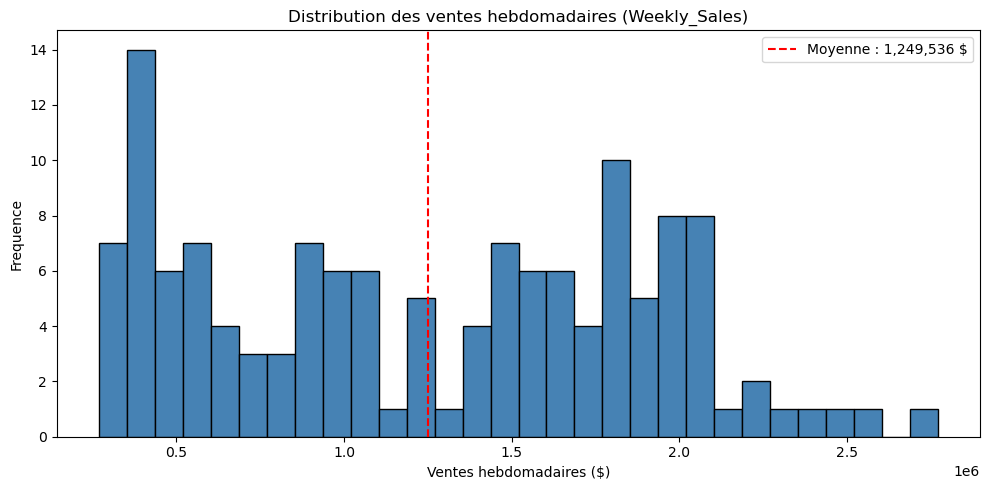

In [34]:
# Distribution de la variable cible : Weekly_Sales
plt.figure(figsize=(10, 5))
plt.hist(df['Weekly_Sales'].dropna(), bins=30, edgecolor='black', color='steelblue')
plt.title('Distribution des ventes hebdomadaires (Weekly_Sales)')
plt.xlabel('Ventes hebdomadaires ($)')
plt.ylabel('Frequence')
plt.axvline(df['Weekly_Sales'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['Weekly_Sales'].mean():,.0f} $")
plt.legend()
plt.tight_layout()
plt.show()

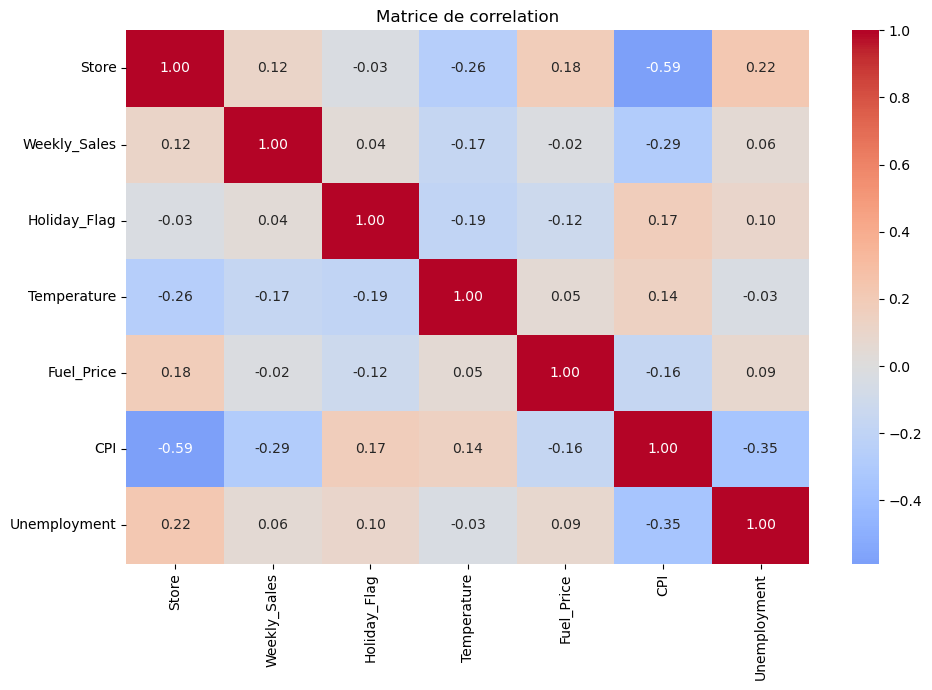

In [35]:
# Matrice de correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10, 7))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matrice de correlation')
plt.tight_layout()
plt.show()

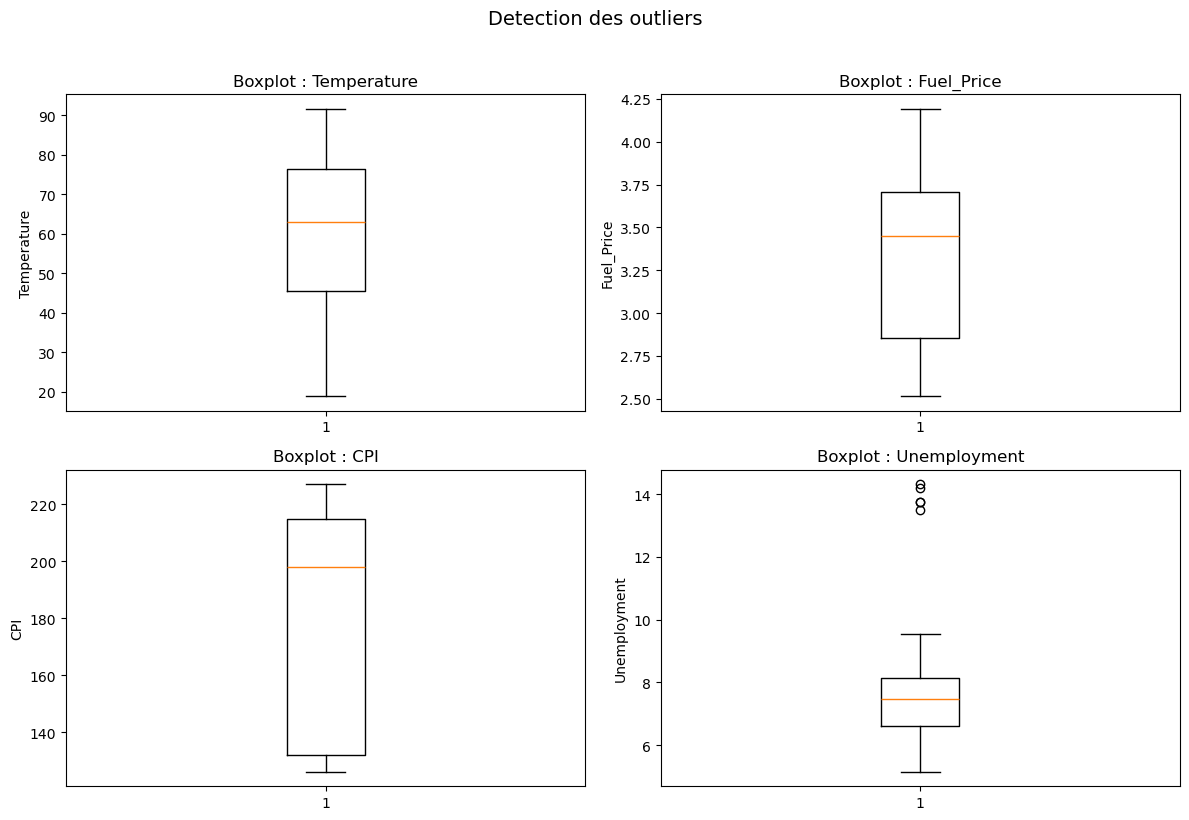

In [36]:
# Boxplots pour detecter les outliers sur les 4 colonnes cibles
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

for idx, col in enumerate(outlier_cols):
    ax = axes[idx // 2, idx % 2]
    ax.boxplot(df[col].dropna())
    ax.set_title(f'Boxplot : {col}')
    ax.set_ylabel(col)

plt.suptitle('Detection des outliers', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

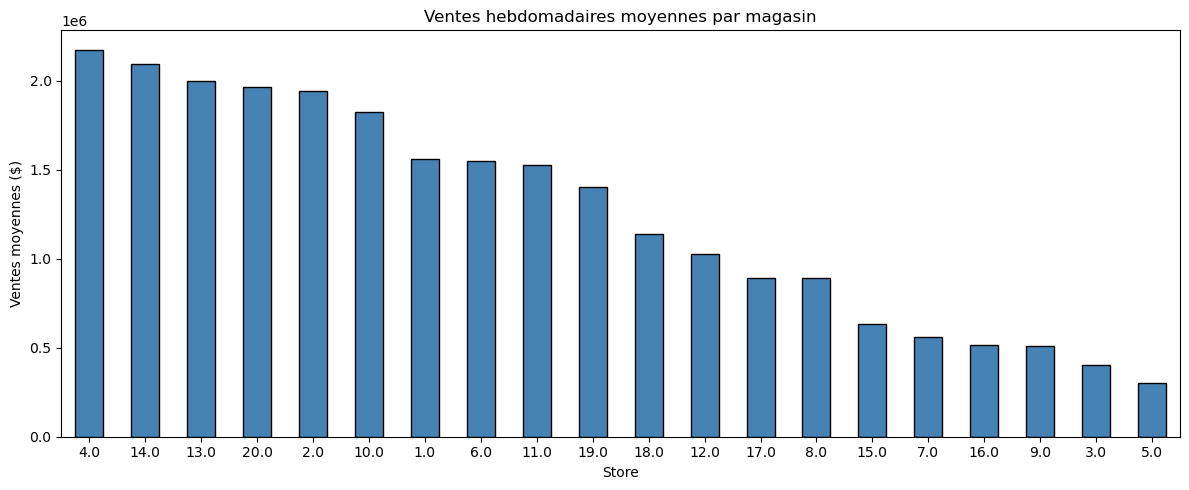

In [37]:
# Ventes moyennes par magasin
plt.figure(figsize=(12, 5))
sales_by_store = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
sales_by_store.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Ventes hebdomadaires moyennes par magasin')
plt.xlabel('Store')
plt.ylabel('Ventes moyennes ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

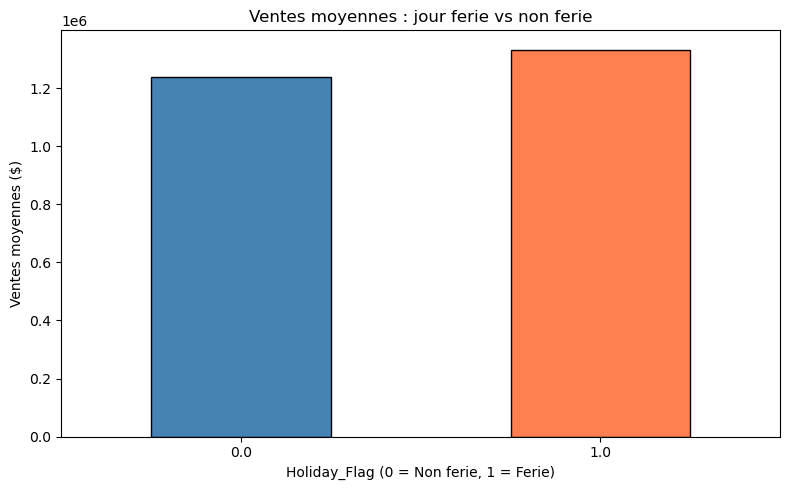

In [38]:
# Impact des jours feries sur les ventes
plt.figure(figsize=(8, 5))
df.groupby('Holiday_Flag')['Weekly_Sales'].mean().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Ventes moyennes : jour ferie vs non ferie')
plt.xlabel('Holiday_Flag (0 = Non ferie, 1 = Ferie)')
plt.ylabel('Ventes moyennes ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**À commenter :** ce graphique permet de voir si les semaines avec jour férié génèrent en moyenne plus ou moins de ventes que les semaines normales — à décrire en fonction du résultat obtenu.

## Etape 3 : Nettoyage des donnees

In [39]:
# 1. Supprimer les lignes ou Weekly_Sales est manquant (jamais d'imputation sur la target)
print(f"Avant : {len(df)} lignes")
df_clean = df.dropna(subset=['Weekly_Sales']).copy()
print(f"Apres suppression NaN Weekly_Sales : {len(df_clean)} lignes ({len(df) - len(df_clean)} supprimees)")

Avant : 150 lignes
Apres suppression NaN Weekly_Sales : 136 lignes (14 supprimees)


In [40]:
# 2. Transformer la colonne Date en features numeriques
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True)
df_clean['Year'] = df_clean['Date'].dt.year
df_clean['Month'] = df_clean['Date'].dt.month
df_clean['Day'] = df_clean['Date'].dt.day
df_clean['DayOfWeek'] = df_clean['Date'].dt.dayofweek  # 0=Lundi, 6=Dimanche

# Supprimer la colonne Date originale
df_clean = df_clean.drop('Date', axis=1)

print("Nouvelles colonnes creees a partir de Date :")
df_clean[['Year', 'Month', 'Day', 'DayOfWeek']].head()

Nouvelles colonnes creees a partir de Date :


,Year,Month,Day,DayOfWeek
0,2011.0,2.0,18.0,4.0
1,2011.0,3.0,25.0,4.0
3,NaN,NaN,NaN,NaN
4,2010.0,5.0,28.0,4.0
5,2010.0,5.0,28.0,4.0


In [41]:
# 3. Supprimer les lignes restantes avec des NaN (features manquantes)
print(f"NaN restants avant nettoyage :\n{df_clean.isnull().sum()}\n")
df_clean = df_clean.dropna()
print(f"Apres suppression de tous les NaN : {len(df_clean)} lignes")

NaN restants avant nettoyage :
Store            0
Weekly_Sales     0
Holiday_Flag    11
Temperature     15
Fuel_Price      12
CPI             11
Unemployment    14
Year            18
Month           18
Day             18
DayOfWeek       18
dtype: int64

Apres suppression de tous les NaN : 75 lignes


In [42]:
# 4. Supprimer les outliers avec la regle des 3-sigma
# Colonnes concernees : Temperature, Fuel_Price, CPI, Unemployment
outlier_cols = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

print(f"Avant suppression des outliers : {len(df_clean)} lignes\n")

for col in outlier_cols:
    mean = df_clean[col].mean()
    std = df_clean[col].std()
    lower = mean - 3 * std
    upper = mean + 3 * std
    
    n_before = len(df_clean)
    df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    n_removed = n_before - len(df_clean)
    
    print(f"{col} : intervalle [{lower:.2f}, {upper:.2f}] -> {n_removed} outlier(s) supprime(s)")

print(f"\nApres suppression des outliers : {len(df_clean)} lignes")

Avant suppression des outliers : 75 lignes

Temperature : intervalle [8.45, 112.49] -> 0 outlier(s) supprime(s)
Fuel_Price : intervalle [1.84, 4.81] -> 0 outlier(s) supprime(s)
CPI : intervalle [55.61, 296.54] -> 0 outlier(s) supprime(s)
Unemployment : intervalle [2.37, 12.95] -> 4 outlier(s) supprime(s)

Apres suppression des outliers : 71 lignes


In [43]:
# Verification du dataset nettoye
print(f"Shape final : {df_clean.shape}")
print(f"\nValeurs manquantes : {df_clean.isnull().sum().sum()}")
df_clean.head()

Shape final : (71, 11)

Valeurs manquantes : 0


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Day,DayOfWeek
1,13.0,1807545.43,0.0,42.38,3.435,128.616064,7.470,2011.0,3.0,25.0,4.0
4,6.0,1644470.66,0.0,78.89,2.759,212.412888,7.092,2010.0,5.0,28.0,4.0
6,15.0,695396.19,0.0,69.80,4.069,134.855161,7.658,2011.0,6.0,3.0,4.0
7,20.0,2203523.20,0.0,39.93,3.617,213.023622,6.961,2012.0,2.0,3.0,4.0
10,8.0,895066.50,0.0,82.92,3.554,219.070197,6.425,2011.0,8.0,19.0,4.0


**Bilan du nettoyage :** le dataset passe de 150 à 71 lignes (-53%), réparties entre les valeurs manquantes sur la cible (14 lignes), les valeurs manquantes sur les autres variables (61 lignes supplémentaires) et 4 outliers sur `Unemployment`. Cette perte importante est une limite du projet à mentionner : avec un échantillon aussi réduit, les résultats obtenus doivent être interprétés avec prudence quant à leur généralisation.

## Etape 4 : Preparation des donnees pour le Machine Learning

In [44]:
# Separer X (features) et y (target)
X = df_clean.drop('Weekly_Sales', axis=1)
y = df_clean['Weekly_Sales']

# Identifier les types de variables
categorical_features = ['Store', 'Holiday_Flag']
numerical_features = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']

print(f"Features (X) : {X.shape}")
print(f"Target (y) : {y.shape}")
print(f"\nVariables categorielles : {categorical_features}")
print(f"Variables numeriques : {numerical_features}")

Features (X) : (71, 10)
Target (y) : (71,)

Variables categorielles : ['Store', 'Holiday_Flag']
Variables numeriques : ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek']


In [45]:
# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape[0]} lignes")
print(f"Test  : {X_test.shape[0]} lignes")

Train : 56 lignes
Test  : 15 lignes


In [46]:
# Preprocessing avec ColumnTransformer :
# - StandardScaler sur les variables numeriques
# - OneHotEncoder sur les variables categorielles
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ]
)

# fit_transform sur le train, transform sur le test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape apres preprocessing :")
print(f"  X_train : {X_train_processed.shape}")
print(f"  X_test  : {X_test_processed.shape}")

Shape apres preprocessing :
  X_train : (56, 26)
  X_test  : (15, 26)


c:\Users\surel\anaconda3\envs\ds_classic\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


**Note :** le warning *"Found unknown categories"* apparait car certains magasins ne sont presents que dans le jeu de test (56 lignes en train pour ~19-20 magasins, soit parfois 1 a 2 observations par magasin). Grace a `handle_unknown='ignore'`, ces cas sont encodes comme un vecteur de zeros plutot que de faire planter le pipeline - mais cela signifie que le modele n'a aucune information specifique sur ces magasins au moment de predire. C'est une consequence directe de la taille reduite de l'echantillon (voir Etape 3).

In [47]:
# Recuperer les noms des features apres preprocessing
feature_names = (
    numerical_features 
    + list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)
print(f"Nombre total de features apres encoding : {len(feature_names)}")
print(f"Features : {feature_names}")

Nombre total de features apres encoding : 26
Features : ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'Day', 'DayOfWeek', 'Store_2.0', 'Store_3.0', 'Store_4.0', 'Store_5.0', 'Store_6.0', 'Store_7.0', 'Store_8.0', 'Store_9.0', 'Store_10.0', 'Store_13.0', 'Store_14.0', 'Store_15.0', 'Store_16.0', 'Store_17.0', 'Store_18.0', 'Store_19.0', 'Store_20.0', 'Holiday_Flag_1.0']


# PARTIE 2 : Modele Baseline (Regression Lineaire)

## Etape 5 : Entrainement du modele de regression lineaire

In [48]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Entrainer le modele
lr_model = LinearRegression()
lr_model.fit(X_train_processed, y_train)

# Predictions sur train et test
y_train_pred = lr_model.predict(X_train_processed)
y_test_pred = lr_model.predict(X_test_processed)

print("Modele de regression lineaire entraine.")

Modele de regression lineaire entraine.


## Etape 6 : Evaluation des performances

In [49]:
# Fonction d'evaluation reutilisable
def evaluate_model(y_true, y_pred, dataset_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"=== {dataset_name} ===")
    print(f"  RMSE : {rmse:,.2f} $")
    print(f"  MAE  : {mae:,.2f} $")
    print(f"  R2   : {r2:.4f}")
    print()
    return {'rmse': rmse, 'mae': mae, 'r2': r2}

# Evaluer sur train et test
print("REGRESSION LINEAIRE\n")
lr_train_scores = evaluate_model(y_train, y_train_pred, "TRAIN")
lr_test_scores = evaluate_model(y_test, y_test_pred, "TEST")

# Diagnostic overfitting
r2_diff = lr_train_scores['r2'] - lr_test_scores['r2']
if r2_diff > 0.1:
    print(f"Ecart R2 train/test = {r2_diff:.4f} -> Signe d'overfitting")
else:
    print(f"Ecart R2 train/test = {r2_diff:.4f} -> Pas d'overfitting majeur")

REGRESSION LINEAIRE

=== TRAIN ===
  RMSE : 83,129.39 $
  MAE  : 66,020.21 $
  R2   : 0.9865

=== TEST ===
  RMSE : 149,684.57 $
  MAE  : 127,770.23 $
  R2   : 0.9313

Ecart R2 train/test = 0.0552 -> Pas d'overfitting majeur


**Lecture des résultats :** le R² de 0.987 en train et 0.931 en test, avec un écart de seulement 0.055, indique que le modèle généralise correctement malgré la taille réduite du jeu d'entraînement (56 lignes) : pas de signe d'overfitting majeur.

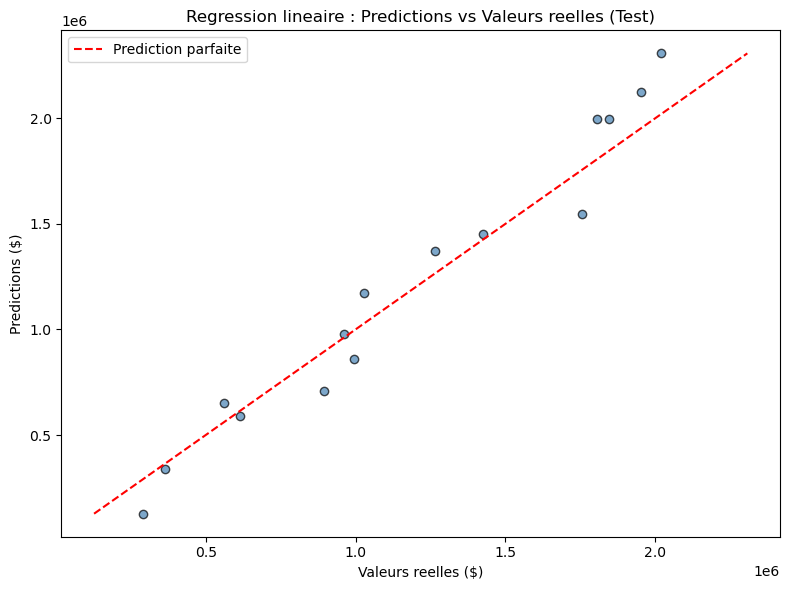

In [50]:
# Visualisation : predictions vs valeurs reelles
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_test_pred, color='steelblue', edgecolor='black', alpha=0.7)

# Ligne de prediction parfaite
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Prediction parfaite')

plt.xlabel('Valeurs reelles ($)')
plt.ylabel('Predictions ($)')
plt.title('Regression lineaire : Predictions vs Valeurs reelles (Test)')
plt.legend()
plt.tight_layout()
plt.show()

## Etape 7 : Interpretation des coefficients

In [51]:
# Analyser les coefficients du modele
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})
coef_df['Abs_Coefficient'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print(f"Intercept : {lr_model.intercept_:,.2f}\n")
print("Coefficients tries par importance :")
print(coef_df.to_string(index=False))

Intercept : 986,225.82

Coefficients tries par importance :
         Feature   Coefficient  Abs_Coefficient
       Store_4.0  2.112972e+06     2.112972e+06
      Store_13.0  1.975536e+06     1.975536e+06
      Store_10.0  1.909599e+06     1.909599e+06
       Store_5.0 -1.374982e+06     1.374982e+06
       Store_9.0 -1.332161e+06     1.332161e+06
       Store_3.0 -1.310759e+06     1.310759e+06
      Store_19.0  1.310019e+06     1.310019e+06
      Store_14.0  1.259366e+06     1.259366e+06
      Store_18.0  9.904759e+05     9.904759e+05
       Store_8.0 -8.982085e+05     8.982085e+05
      Store_16.0 -7.481323e+05     7.481323e+05
             CPI  7.148366e+05     7.148366e+05
       Store_7.0 -6.511288e+05     6.511288e+05
      Store_17.0  6.182832e+05     6.182832e+05
      Store_15.0  6.015770e+05     6.015770e+05
      Store_20.0  5.140257e+05     5.140257e+05
       Store_2.0  2.093604e+05     2.093604e+05
Holiday_Flag_1.0 -1.416612e+05     1.416612e+05
       Store_6.0  1.245011e+

**Interprétation :** les coefficients associés aux magasins (`Store_*`) dominent très largement l'importance des variables (jusqu'à ±2 millions), loin devant les indicateurs économiques. Cela suggère que le magasin lui-même (taille, zone de chalandise, profil de clientèle) est le facteur le plus déterminant des ventes hebdomadaires, davantage que la conjoncture économique. Le CPI est le second facteur le plus influent.

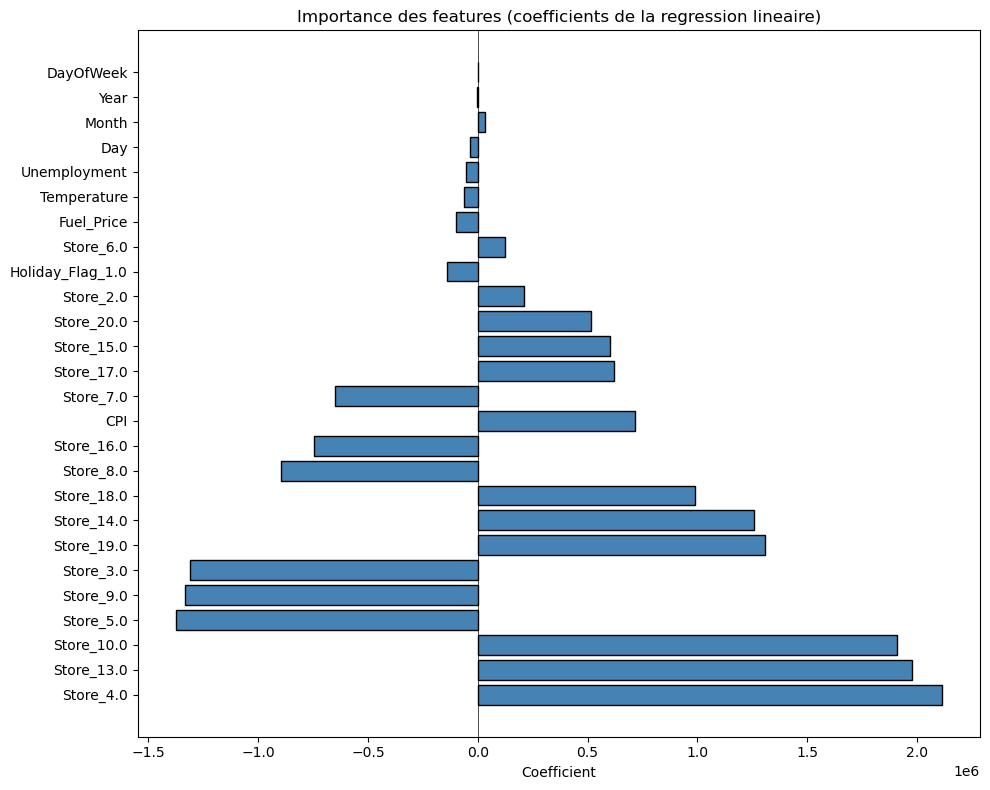

In [52]:
# Visualisation des coefficients
plt.figure(figsize=(10, 8))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue', edgecolor='black')
plt.axvline(x=0, color='black', linewidth=0.5)
plt.xlabel('Coefficient')
plt.title('Importance des features (coefficients de la regression lineaire)')
plt.tight_layout()
plt.show()

# PARTIE 3 : Regularisation (Ridge et Lasso)

## Etape 8 : Modele Ridge

In [53]:
from sklearn.linear_model import Ridge, Lasso

# Entrainer Ridge avec alpha=1.0
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_processed, y_train)

y_train_pred_ridge = ridge_model.predict(X_train_processed)
y_test_pred_ridge = ridge_model.predict(X_test_processed)

print("RIDGE (alpha=1.0)\n")
ridge_train_scores = evaluate_model(y_train, y_train_pred_ridge, "TRAIN")
ridge_test_scores = evaluate_model(y_test, y_test_pred_ridge, "TEST")

RIDGE (alpha=1.0)

=== TRAIN ===
  RMSE : 208,798.23 $
  MAE  : 164,563.08 $
  R2   : 0.9148

=== TEST ===
  RMSE : 225,939.89 $
  MAE  : 173,517.99 $
  R2   : 0.8434



**Ridge à alpha=1 :** le R² test chute à 0.843, nettement en dessous du modèle de base (0.931). Une pénalisation trop forte rétrécit uniformément tous les coefficients, y compris ceux qui portaient une vraie information (l'effet magasin) — ce niveau de régularisation par défaut n'est pas adapté à ce jeu de données.

## Etape 9 : Modele Lasso

In [54]:
# Entrainer Lasso avec alpha=1.0
lasso_model = Lasso(alpha=1.0, max_iter=100000)  # max_iter augmente pour assurer la convergence
lasso_model.fit(X_train_processed, y_train)

y_train_pred_lasso = lasso_model.predict(X_train_processed)
y_test_pred_lasso = lasso_model.predict(X_test_processed)

print("LASSO (alpha=1.0)\n")
lasso_train_scores = evaluate_model(y_train, y_train_pred_lasso, "TRAIN")
lasso_test_scores = evaluate_model(y_test, y_test_pred_lasso, "TEST")

# Montrer les coefficients mis a zero par Lasso
lasso_coef = pd.DataFrame({'Feature': feature_names, 'Coefficient': lasso_model.coef_})
n_zero = (lasso_coef['Coefficient'] == 0).sum()
print(f"Lasso a mis {n_zero} coefficient(s) a zero (selection de features automatique)")
if n_zero > 0:
    print(f"Features eliminees : {lasso_coef[lasso_coef['Coefficient'] == 0]['Feature'].tolist()}")

LASSO (alpha=1.0)

=== TRAIN ===
  RMSE : 83,131.65 $
  MAE  : 66,080.10 $
  R2   : 0.9865

=== TEST ===
  RMSE : 149,741.05 $
  MAE  : 127,702.57 $
  R2   : 0.9312

Lasso a mis 1 coefficient(s) a zero (selection de features automatique)
Features eliminees : ['DayOfWeek']


**Lasso à alpha=1 :** contrairement à Ridge, Lasso conserve un R² test de 0.929, proche du modèle de base, tout en éliminant automatiquement la variable `DayOfWeek` (coefficient quasi nul dans la régression linéaire également). La pénalisation L1 semble mieux adaptée ici que la L2.

## Etape 10 (BONUS) : Optimisation de alpha avec GridSearchCV

In [55]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV pour Ridge
param_grid_ridge = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid_ridge,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=0
)
grid_ridge.fit(X_train_processed, y_train)

print("=== RIDGE - GridSearchCV ===")
print(f"Meilleur alpha : {grid_ridge.best_params_['alpha']}")
print(f"Meilleur score CV (neg MSE) : {grid_ridge.best_score_:,.2f}\n")

y_test_pred_best_ridge = grid_ridge.best_estimator_.predict(X_test_processed)
best_ridge_scores = evaluate_model(y_test, y_test_pred_best_ridge, "TEST - Best Ridge")

=== RIDGE - GridSearchCV ===
Meilleur alpha : 0.1
Meilleur score CV (neg MSE) : -113,118,292,819.20

=== TEST - Best Ridge ===
  RMSE : 143,863.42 $
  MAE  : 117,536.26 $
  R2   : 0.9365



**Optimisation de Ridge :** GridSearchCV identifie alpha=0.1 comme meilleur compromis (bien plus faible que la valeur par défaut de 1), portant le R² test à 0.937 — légèrement au-dessus du modèle de base. Une régularisation plus légère suffit ici à stabiliser le modèle sans sacrifier la performance.

In [56]:
# GridSearchCV pour Lasso
param_grid_lasso = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

grid_lasso = GridSearchCV(
    Lasso(max_iter=100000),  # max_iter augmente pour assurer la convergence sur toute la grille
    param_grid_lasso,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=0
)
grid_lasso.fit(X_train_processed, y_train)

print("=== LASSO - GridSearchCV ===")
print(f"Meilleur alpha : {grid_lasso.best_params_['alpha']}")
print(f"Meilleur score CV (neg MSE) : {grid_lasso.best_score_:,.2f}\n")

y_test_pred_best_lasso = grid_lasso.best_estimator_.predict(X_test_processed)
best_lasso_scores = evaluate_model(y_test, y_test_pred_best_lasso, "TEST - Best Lasso")

=== LASSO - GridSearchCV ===
Meilleur alpha : 100
Meilleur score CV (neg MSE) : -126,957,326,103.62

=== TEST - Best Lasso ===
  RMSE : 149,845.14 $
  MAE  : 124,939.90 $
  R2   : 0.9311



**Optimisation de Lasso :** l'alpha optimal trouvé (100) est nettement plus élevé que pour Ridge, ce qui traduit une régularisation plus forte nécessaire pour stabiliser Lasso sur ce jeu de données. Le score obtenu (R²=0.931) reste très proche du Lasso à alpha=1 et de la régression linéaire simple : sur ce dataset, Lasso apporte surtout un intérêt en termes de sélection de variables (élimination de DayOfWeek) plus qu'un gain de performance.

## Comparaison finale des modeles

In [57]:
# Tableau comparatif de tous les modeles
comparison = pd.DataFrame({
    'Modele': [
        'Linear Regression',
        'Ridge (alpha=1)',
        'Lasso (alpha=1)',
        f'Ridge GridSearch (alpha={grid_ridge.best_params_["alpha"]})',
        f'Lasso GridSearch (alpha={grid_lasso.best_params_["alpha"]})'
    ],
    'R2 Test': [
        lr_test_scores['r2'],
        ridge_test_scores['r2'],
        lasso_test_scores['r2'],
        best_ridge_scores['r2'],
        best_lasso_scores['r2']
    ],
    'RMSE Test': [
        lr_test_scores['rmse'],
        ridge_test_scores['rmse'],
        lasso_test_scores['rmse'],
        best_ridge_scores['rmse'],
        best_lasso_scores['rmse']
    ]
})

comparison = comparison.sort_values('R2 Test', ascending=False)
print("=== COMPARAISON FINALE ===\n")
print(comparison.to_string(index=False))

=== COMPARAISON FINALE ===

                      Modele  R2 Test     RMSE Test
Ridge GridSearch (alpha=0.1) 0.936520 143863.424328
           Linear Regression 0.931279 149684.574574
             Lasso (alpha=1) 0.931227 149741.045130
Lasso GridSearch (alpha=100) 0.931132 149845.142542
             Ridge (alpha=1) 0.843426 225939.893247


**Synthèse :** le meilleur modèle est le Ridge optimisé par GridSearch (alpha=0.1, R²=0.937), suivi de très près par la régression linéaire simple (R²=0.931). Les modèles régularisés avec alpha=1 par défaut (Ridge en particulier) sous-performent, ce qui montre l'importance de l'optimisation de l'hyperparamètre plutôt que l'usage d'une valeur par défaut.

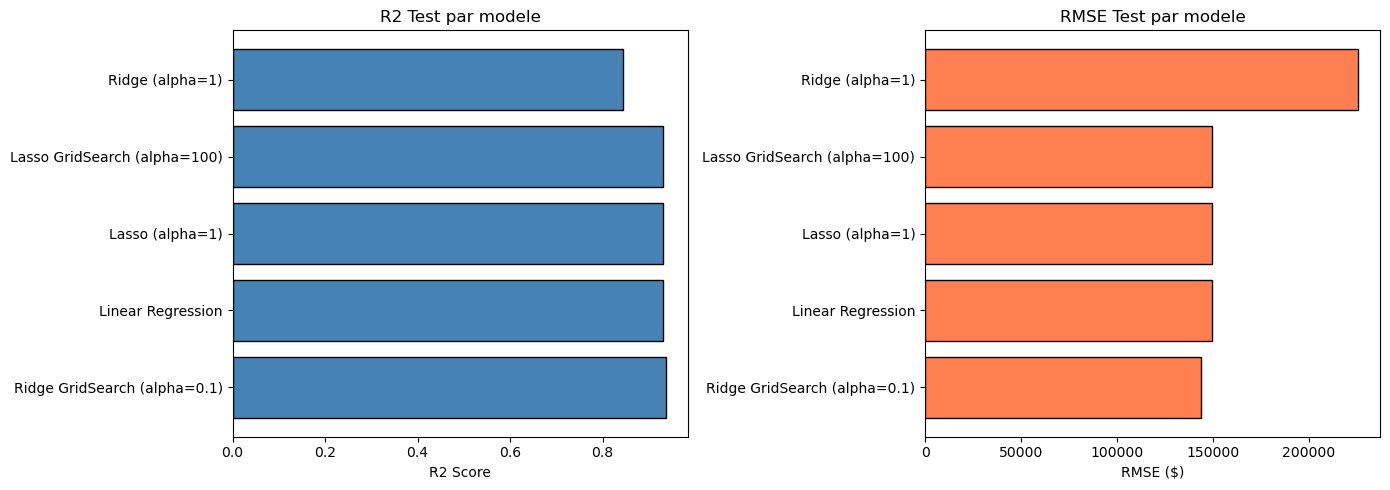

In [58]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R2
axes[0].barh(comparison['Modele'], comparison['R2 Test'], color='steelblue', edgecolor='black')
axes[0].set_xlabel('R2 Score')
axes[0].set_title('R2 Test par modele')

# RMSE
axes[1].barh(comparison['Modele'], comparison['RMSE Test'], color='coral', edgecolor='black')
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('RMSE Test par modele')

plt.tight_layout()
plt.show()

## Conclusion

Ce projet a permis d'entraîner et de comparer trois familles de modèles de régression pour prédire les ventes hebdomadaires des magasins Walmart à partir d'indicateurs économiques et de la date.

**Résultats principaux :**
- Le modèle de régression linéaire de base atteint déjà un R² test de 0.931, sans signe d'overfitting majeur.
- Le magasin est le facteur le plus déterminant des ventes, devant les indicateurs économiques (CPI, Fuel_Price, Unemployment, Temperature).
- La régularisation Ridge, mal calibrée par défaut (alpha=1), dégrade la performance (R²=0.843), mais une fois optimisée via GridSearchCV (alpha=0.1), elle devient le meilleur modèle du projet (R²=0.937).
- Lasso confirme la faible utilité de la variable `DayOfWeek`, qu'il élimine automatiquement.

**Limites :**
- Le nettoyage des données a réduit l'échantillon de 150 à 71 lignes (-53%), ce qui limite la robustesse statistique des résultats, en particulier pour les magasins peu représentés.
- Le One-Hot Encoding de la variable `Store` sur un échantillon aussi petit peut conduire à des coefficients instables pour les magasins sous-représentés dans le jeu d'entraînement.
- Des pistes d'amélioration possibles : imputation des variables explicatives (hors cible) plutôt que suppression systématique des lignes, pour conserver davantage d'observations.